In [26]:
# ====================================================================
# 0. imports & reproducibility
# ====================================================================
import pandas as pd, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tcn import TCN
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from pathlib import Path
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adamax, Nadam, Adadelta

rng = np.random.default_rng(42)
tf.keras.utils.set_random_seed(42)
tf.debugging.enable_check_numerics()          # crash early on NaN/Inf

INFO:tensorflow:Enabled check-numerics callback in thread MainThread


In [27]:
# ------------------------------------------------------------------
# files you want to merge  (add as many as you like)
# ------------------------------------------------------------------
FILES = [
    "previous_dv0_withstraw_sipCAdded.xlsx", 
    # "dv0_withstraw_sipCAdded.xlsx",
                       # ← put your second file name here
    # "third_file.xlsx",
]

In [28]:
# ------------------------------------------------------------------
# read & re-index
# ------------------------------------------------------------------
dfs          = []
next_offset  = 0          # keeps track of the next free Participant_ID

for fp in FILES:
    fp = Path(fp)
    df = pd.read_excel(fp)

    # current file's min/max before shifting (optional print for sanity)
    old_min, old_max = df["Participant_ID"].min(), df["Participant_ID"].max()
    print(f"{fp.name}: original IDs {old_min} … {old_max}")

    # shift IDs so they don't collide with previous files
    df["Participant_ID"] += next_offset

    # update next_offset for the *next* file
    next_offset = df["Participant_ID"].max() + 1

    # done
    dfs.append(df)
    print(f"   shifted to {df['Participant_ID'].min()} … {df['Participant_ID'].max()}")


previous_dv0_withstraw_sipCAdded.xlsx: original IDs 9 … 59
   shifted to 9 … 59


In [29]:
# ------------------------------------------------------------------
# combined DataFrame
# ------------------------------------------------------------------
df_all = pd.concat(dfs, ignore_index=True)
print("\nMerged dataframe shape:", df_all.shape)
print("Global Participant_ID range:", df_all["Participant_ID"].min(),
      "…", df_all["Participant_ID"].max())


Merged dataframe shape: (30949, 82)
Global Participant_ID range: 9 … 59


In [30]:
df_all

,Unnamed: 0,Time,Zone_0,Zone_1,Zone_2,Zone_3,Zone_4,Zone_5,Zone_6,Zone_7,...,Container_Weight,drink,temp,prev,next,sip_start,sip_end,sip_id,dV,TOTAL_SIP_TIME
0,0,1747827431000,284,222,261,317,268,310,2246,2378,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
1,1,1747827431200,284,222,248,317,268,310,2246,2337,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
2,2,1747827431400,284,222,248,317,268,310,2246,2378,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
3,3,1747827431600,284,222,248,317,276,310,2246,2337,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
4,4,1747827431800,284,222,248,317,276,310,2246,2337,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30944,30944,1748022490800,217,213,223,230,211,204,234,208,...,12.7,water,n,0,0,False,False,5,0.0,0
30945,30945,1748022491000,217,215,223,230,210,204,214,207,...,12.7,water,n,0,0,False,False,5,0.0,0
30946,30946,1748022491200,207,208,226,228,210,201,214,208,...,12.7,water,n,0,0,False,False,5,0.0,0
30947,30947,1748022491400,206,203,226,222,202,179,194,204,...,12.7,water,n,0,0,False,False,5,0.0,0


In [31]:
df = df_all

In [32]:
# print("Label stats  (raw, before scaling)")
# print("  min :", y.min())
# print("  #zeros :", (y == 0).sum())
# print("  any negative? ", (y < 0).any())

In [33]:

# --------------------------------------------------------------------
# user settings
# --------------------------------------------------------------------

BATCH      = 1                                   # 1 = ragged, >1 = padded


In [34]:
# ====================================================================
# 1. load data  ➜  X(list of (T,64)), y(array)   – SKIP zero-volume sips
# ====================================================================
df = df[df["Label"] == 1]                        # keep only annotated frames

feature_cols = df.columns[2:66]
seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

X, y = [], []
skip_count = 0

for _, g in df.groupby(seq_keys, sort=False):
    dV = float(g[label_col].iloc[0])
    if dV == 0.0:                                # ← drop empty sip
        skip_count += 1
        continue
    X.append(g[feature_cols].to_numpy(np.float32))   # (T,64)
    y.append(dV)

y = np.asarray(y, np.float32)
X = np.array(X, dtype=object)   # each element is still a (T,64) array
print(f"Total sips kept : {len(X)}")
print(f"Zero-volume skipped : {skip_count}")
print("Label stats  → min:", y.min(), "max:", y.max())

Total sips kept : 152
Zero-volume skipped : 0
Label stats  → min: 0.8 max: 90.2


In [35]:
X[:1]

array([array([[107., 100.,  99., ..., 150., 156., 144.],
              [107., 100.,  99., ..., 150., 156., 144.],
              [106., 100.,  98., ..., 150., 156., 138.],
              ...,
              [190., 169., 165., ..., 166., 179., 197.],
              [187., 163., 161., ..., 169., 180., 197.],
              [182., 162., 157., ..., 169., 182., 197.]], dtype=float32)],
      dtype=object)

In [36]:
print(type(X))          # <class 'numpy.ndarray'>
print(X.shape)          # (number,)

print(type(X[0]))       # <class 'numpy.ndarray'>
print(X[0].shape)       # (rows, columns)

<class 'numpy.ndarray'>
(152,)
<class 'numpy.ndarray'>
(17, 64)


In [37]:
# ====================================================================
# 2. shuffle whole sips ➜ 80 / 20 split
# ====================================================================
idx = rng.permutation(len(X))
split1 = int(.64 * len(X))          # 64 % train
split2 = int(.80 * len(X))          # next 16 % val
X_train, y_train = X[idx[:split1]], y[idx[:split1]]
X_val,   y_val   = X[idx[split1:split2]], y[idx[split1:split2]]
X_test,  y_test  = X[idx[split2:]], y[idx[split2:]]
print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")
# y_train_s = np.log1p(y_train)        # log1p for numerical safety
# y_val_s   = np.log1p(y_val)
# y_test_s  = np.log1p(y_test)


Train 97 Val 24  Test 31


In [38]:
# X_train


In [39]:
# y_train

In [40]:
# ====================================================================
# 3. column-wise z-score normalisation (fit on training only)
# ====================================================================
mat_train = np.vstack(X_train)          # ⬅ only TRAIN data
mean64 = mat_train.mean(0, keepdims=True)
std64  = mat_train.std(0,  keepdims=True) + 1e-8

norm = lambda seq: (seq - mean64) / std64
X_train = [norm(s) for s in X_train]
X_val   = [norm(s) for s in X_val]
X_test  = [norm(s) for s in X_test]

# # label scaling
# y_max   = y_train.max() or 1.
# y_train_s = y_train / y_max
# y_val_s   = y_val   / y_max
# y_test_s  = y_test  / y_max
y_train_s = y_train 
y_val_s   = y_val   
y_test_s  = y_test  



In [41]:
# X_train

In [42]:
# ====================================================================
# 4. tf.data pipelines
# ====================================================================
def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),
    tf.TensorSpec((),          tf.float32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(lambda: generator(xs, ys),
                                        output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if BATCH == 1:
        return ds.repeat().batch(1)              # ragged
    return ds.repeat().padded_batch(             # padded
        BATCH,
        padded_shapes=([None, 64], []),
        padding_values=(0.0, 0.0)
    )

train_ds = make_ds(X_train, y_train_s, shuffle=True)
val_ds   = make_ds(X_val,   y_val_s,   shuffle=False)
test_ds  = make_ds(X_test,  y_test_s,  shuffle=False)

In [43]:
train_ds

<_BatchDataset element_spec=(TensorSpec(shape=(None, None, 64), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

In [44]:
# for batch in train_ds.take(1):
#     x_batch, y_batch = batch
#     print("x_batch shape:", x_batch.shape)
#     print("y_batch shape:", y_batch.shape)
#     print("x_batch:", x_batch.numpy())
#     print("y_batch:", y_batch.numpy())

In [45]:
# ====================================================================
# 5. model  – TCN ➜ Dense(1, softplus) keeps output ≥ 0
# ====================================================================
inp = tf.keras.Input(shape=(None, 64))
x = TCN(nb_filters=128,
        kernel_size=2,
        dilations=[1,2,4,8,16,32],   # ~64-time-step field
        dropout_rate=0.1,
        return_sequences=False)(inp)
out = tf.keras.layers.Dense(1)(x)          # ← LINEAR output
model = tf.keras.Model(inp, out)

model.compile(
    # tf.keras.optimizers.Adam(1e-3),        # a bit faster
    optimizer=Adagrad(learning_rate=0.01),
    loss="mae"                             # MAE is more robust
)
model.summary()

steps_per_epoch = len(X_train) // BATCH + (len(X_train) % BATCH > 0)
val_steps       = len(X_val)   // BATCH + (len(X_val)   % BATCH > 0)
# weights = (y_train / y_train.max()) ** 0.5  
cb = tf.keras.callbacks.EarlyStopping(
         monitor='val_loss', patience=15, restore_best_weights=True)
model.fit(
    train_ds,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,        # ⬅ use VALIDATION set
    validation_steps=val_steps,
    verbose=1,
    # sample_weight=weights,
    callbacks=[cb]
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_1 (TCN)                     │ (None, 128)            │       386,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,817 (1.48 MB)

 Trainable params: 386,817 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 27.3106 - val_loss: 10.6806
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.1134 - val_loss: 7.8291
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.9746 - val_loss: 8.3391
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.7456 - val_loss: 6.8055
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.1275 - val_loss: 7.1488
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.3051 - val_loss: 13.1507
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.2773 - val_loss: 7.0706
Epoch 8/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2590 - val_loss: 7.8287
Epoch 9/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.1268 - val_loss: 8.0058
Epoch 10/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.9381 - val_loss: 7.7389
Epoch 11/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.7227 - val_loss: 7.3708
Epoch 12/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.1949 - va

In [46]:
# ====================================================================
# 6. inference on test set (un-scale predictions)
# ====================================================================
y_pred_s = np.array([model.predict(seq[None, ...], verbose=0)[0, 0]
                     for seq in X_test])
# inverse transform after prediction
# y_pred_s = np.expm1(y_pred_s)
# y_pred   = y_pred_s * y_max
y_pred = y_pred_s
y_mean, y_std = y_train.mean(), y_train.std()
y_train_s = (y_train - y_mean) / y_std
# ...
# y_pred = y_pred_s * y_std + y_mean       # undo scaling

In [47]:
# ====================================================================
# 7. evaluation
# ====================================================================
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

non_zero = y_test != 0
rmspe = (np.sqrt(np.mean(((y_test[non_zero]-y_pred[non_zero]) /
                          y_test[non_zero])**2))*100
         if non_zero.any() else np.nan)

print(f"\nEvaluation on {len(y_test)} test sips")
print(f"  MSE   : {mse:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  R²    : {r2:.4f}")
print(f"  RMSPE : {rmspe:.2f}%")

comparison_df = pd.DataFrame({"Actual dV": y_test, "Predicted dV": y_pred})
print("\nFirst 50 predictions:")
print(comparison_df.head(50))


Evaluation on 31 test sips
  MSE   : 217.6655
  RMSE  : 14.7535
  R²    : 0.4049
  RMSPE : 92.55%

First 50 predictions:
    Actual dV  Predicted dV
0   18.799999     30.281206
1   61.400002     48.880825
2    6.100000     34.501102
3   11.142858      9.129046
4   29.100000     30.532757
5   90.199997     30.120844
6   38.400002     25.900385
7   15.475024     12.834991
8   11.100000     27.545002
9   10.761905      8.987533
10  11.619047      7.133587
11  57.786484     32.115086
12  10.476191      7.265311
13  15.100000     17.608051
14  40.450539     40.223087
15  14.666667     13.846344
16  23.600000     18.368256
17  11.000000     10.116434
18  12.732615     11.139359
19  27.299999     20.195654
20  18.476191     19.483841
21  16.571428     12.157888
22  24.900000     33.379700
23  14.397650     18.913151
24  24.400000     29.835491
25  11.600000     15.509298
26  58.400002     49.263733
27  13.600000     18.747913
28  10.285714      6.972674
29  43.700001     20.483776
30  21.400

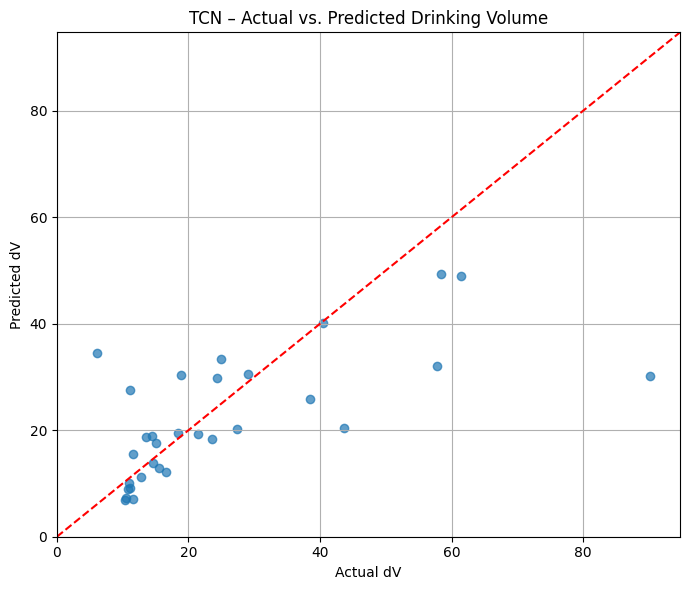

In [48]:
# ====================================================================
# 8. scatter plot
# ====================================================================
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
lims = [0, max(y_test.max(), y_pred.max()) * 1.05]
plt.plot(lims, lims, "r--")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual dV"); plt.ylabel("Predicted dV")
plt.title("TCN – Actual vs. Predicted Drinking Volume")
plt.grid(True); plt.tight_layout(); plt.show()

In [49]:
# print("First 5 log targets  :", y_train_s[:5])
# print("First 5 raw targets  :", y_train[:5])

# # after one epoch
# raw_pred = np.expm1(model.predict(X_val[:3])[...,0])
# print("First 3 un-scaled predictions:", raw_pred)

In [50]:
print("train  min / max (ml):", y_train.min(), y_train.max())
print("train_s min / max (log):", y_train_s.min(), y_train_s.max())

# quick expectation check:  ln(1+160) ≈ 5.08
#                           ln(1+  5) ≈ 1.79

train  min / max (ml): 0.8 77.4
train_s min / max (log): -1.6265295 3.473631
